In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
folder_path = "evaluate/batch1"

In [3]:
data_list = []
for file_name in os.listdir(folder_path):
    if file_name.endswith("_metrics_summary.csv"):
        model_name = "_".join(file_name.split("_")[:-2])
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path)
        df["model_name"] = model_name
        data_list.append(df)

all_data = pd.concat(data_list)

### Anzahl der ausgegebenen Files

In [4]:
all_data["percentage_correct_files"] = (all_data["num_nct_files"] / all_data["num_files"]) * 100
result = all_data.groupby("model_name").agg(
    percentage_correct_files=("percentage_correct_files", "mean"),
    num_nct_files=("num_nct_files", "first"),
    num_files=("num_files", "first")
).reset_index()
result["percentage_correct_files"] = result["percentage_correct_files"].apply(lambda x: f"{x:.2f}%")
result["percentage_correct_files"] = result.apply(
    lambda x: f"{x['percentage_correct_files']} ({x['num_nct_files']}/{x['num_files']})", axis=1
)
result = result[["model_name", "percentage_correct_files"]]
print(result)

                               model_name percentage_correct_files
0             Llama-3-70B-Instruct_5_shot         80.33% (241/300)
1      Llama-3-70B-Instruct_prompt_5_shot         82.00% (246/300)
2              Llama-3-8B-Instruct_4_shot         45.39% (138/304)
3  Llama-3-8B-Instruct_temp_4_shot_temp_1         38.82% (118/304)


In [9]:
all_data

,Unnamed: 0,accuracy,precision,recall,f1_score,pct_greater,pct_less,pct_equal,num_nct_files,model_name,num_files,mean_jacard,mean_bleu,percentage_correct_files
0,AND,0.290,0.290,0.290,0.286,26.97,43.98,29.05,241,Llama-3-70B-Instruct_5_shot,300,0.936259,0.638616,80.333333
1,OR,0.378,0.332,0.378,0.343,18.26,43.98,37.76,241,Llama-3-70B-Instruct_5_shot,300,0.936259,0.638616,80.333333
2,NOT,0.714,0.650,0.714,0.655,5.39,23.24,71.37,241,Llama-3-70B-Instruct_5_shot,300,0.936259,0.638616,80.333333
3,DEPTH,0.228,0.213,0.228,0.213,13.69,63.49,22.82,241,Llama-3-70B-Instruct_5_shot,300,0.936259,0.638616,80.333333
0,AND,0.289,0.280,0.289,0.282,26.42,44.72,28.86,246,Llama-3-70B-Instruct_prompt_5_shot,300,0.932429,0.634424,82.000000
1,OR,0.362,0.317,0.362,0.328,18.29,45.53,36.18,246,Llama-3-70B-Instruct_prompt_5_shot,300,0.932429,0.634424,82.000000
2,NOT,0.732,0.672,0.732,0.667,3.66,23.17,73.17,246,Llama-3-70B-Instruct_prompt_5_shot,300,0.932429,0.634424,82.000000
3,DEPTH,0.215,0.211,0.215,0.203,14.63,63.82,21.54,246,Llama-3-70B-Instruct_prompt_5_shot,300,0.932429,0.634424,82.000000
0,AND,0.167,0.105,0.167,0.124,21.01,62.32,16.67,138,Llama-3-8B-Instruct_4_shot,304,0.846446,0.357752,45.394737
1,OR,0.283,0.290,0.283,0.279,36.96,34.78,28.26,138,Llama-3-8B-Instruct_4_shot,304,0.846446,0.357752,45.394737


### BLEU und Jacard Vergleich

In [10]:
grouped_data = all_data.groupby('model_name')[['mean_jacard', 'mean_bleu']].first().reset_index()
print(grouped_data)

                               model_name  mean_jacard  mean_bleu
0             Llama-3-70B-Instruct_5_shot     0.936259   0.638616
1      Llama-3-70B-Instruct_prompt_5_shot     0.932429   0.634424
2              Llama-3-8B-Instruct_4_shot     0.846446   0.357752
3  Llama-3-8B-Instruct_temp_4_shot_temp_1     0.848453   0.367716


#### F1 Score der Operatoren

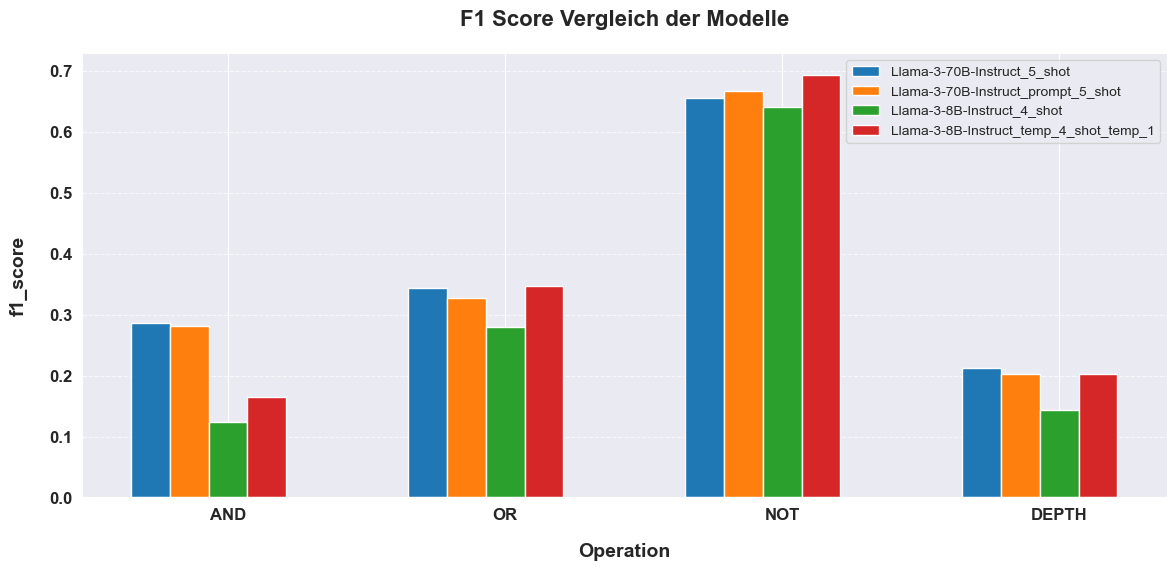

In [5]:
model_names_70B = [name for name in all_data["model_name"].unique() if "70B" in name]
model_names_8B = [name for name in all_data["model_name"].unique() if "8B" in name]


plt.figure(figsize=(14, 6))

operations = all_data["Unnamed: 0"].unique()
bar_width = 0.14
gap = 0 #0.05 
r = range(len(operations))

for i, model_name in enumerate(model_names_70B):
    model_data = all_data[all_data["model_name"] == model_name]
    plt.bar([x + i * bar_width for x in r], model_data["f1_score"], width=bar_width, label=model_name)

offset = len(model_names_70B) * bar_width + gap
for i, model_name in enumerate(model_names_8B):
    model_data = all_data[all_data["model_name"] == model_name]
    plt.bar([x + offset + i * bar_width for x in r], model_data["f1_score"], width=bar_width, label=model_name)

plt.xlabel("Operation", fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel("f1_score", fontsize=14, fontweight='bold', labelpad=15)
plt.title("F1 Score Vergleich der Modelle", fontsize=16, fontweight='bold', pad=20)

plt.xticks(ticks=[r + (len(model_names_70B) + len(model_names_8B)) * bar_width / 2 for r in range(len(operations))], labels=operations, fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.subplots_adjust(top=0.85)
plt.show()

In [6]:
# Modellnamen nach Kategorien filtern
model_names_70B = [name for name in all_data["model_name"].unique() if "70B" in name]
model_names_8B = ['Llama-3-8B-Instruct_3_shot', 'Llama-3-8B-Instruct_4_shot', 'Llama-3-8B-Instruct_5_shot']
model_names_8B_gradient = ['Llama-3-8B-Instruct-Gradient-1048k_10_shot', 'Llama-3-8B-Instruct-Gradient-1048k_20_shot']

# Erstelle den Histogramm-Plot für f1_score
plt.figure(figsize=(14, 6))

operations = all_data["Unnamed: 0"].unique()
bar_width = 0.14
gap = 0  # 0.05
r = range(len(operations))

# Definiere Farbgruppen
colors_70B = ['#1f77b4', '#377eb8', '#6baed6', '#9ecae1']  # verschiedene Blautöne für 70B Modelle
colors_8B = ['#ff7f0e', '#ff9d0e', '#ffbb78', '#ffab58']  # verschiedene Rottöne für 8B Modelle
colors_8B_gradient = ['#2ca02c', '#4daf4a']

# Plot für 70B Modelle
for i, model_name in enumerate(model_names_70B):
    model_data = all_data[all_data["model_name"] == model_name]
    plt.bar([x + i * bar_width for x in r], model_data["f1_score"], width=bar_width, color=colors_70B[i % len(colors_70B)], label=model_name)

# Plot für 8B Modelle
offset = len(model_names_70B) * bar_width + gap
for i, model_name in enumerate(model_names_8B):
    model_data = all_data[all_data["model_name"] == model_name]
    plt.bar([x + offset + i * bar_width for x in r], model_data["f1_score"], width=bar_width, color=colors_8B[i % len(colors_8B)], label=model_name)

# Plot für 8B gradient Modelle
offset += len(model_names_8B) * bar_width + gap
for i, model_name in enumerate(model_names_8B_gradient):
    model_data = all_data[all_data["model_name"] == model_name]
    plt.bar([x + offset + i * bar_width for x in r], model_data["f1_score"], width=bar_width, color=colors_8B_gradient[i % len(colors_8B_gradient)], label=model_name)

plt.xlabel("Operation", fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel("f1_score", fontsize=14, fontweight='bold', labelpad=15)
plt.title("F1 Score Vergleich der Modelle", fontsize=16, fontweight='bold', pad=20)

plt.xticks(ticks=[r + (len(model_names_70B) + len(model_names_8B) + len(model_names_8B_gradient)) * bar_width / 2 for r in range(len(operations))], labels=operations, fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.subplots_adjust(top=0.85)
plt.show()

In [7]:
def plot_metric(data, metric, title, ylabel, xlabel="Operation", figsize=(12, 8)):
    plt.figure(figsize=figsize)

    for model_name, group in data.groupby("model_name"):
        plt.plot(group[metric], label=model_name, marker='o')

    plt.xlabel(xlabel, fontsize=12, fontweight='bold', labelpad=15)
    plt.ylabel(ylabel, fontsize=12, fontweight='bold', labelpad=15)
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    operations = data["Unnamed: 0"].unique()
    plt.xticks(ticks=range(len(operations)), labels=operations, fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12)
    plt.legend(fontsize=10, loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.subplots_adjust(top=0.85)
    plt.show()


### ML Metriken  Vergleich

In [8]:
plot_metric(all_data, "f1_score", "F1 Score der Modelle", "f1_score")
plot_metric(all_data, "accuracy", "Accuracy der Modelle", "accuracy")
plot_metric(all_data, "precision", "Precision der Modelle", "precision")
plot_metric(all_data, "recall", "Recall der Modelle", "recall")

### PCT Vergleich

In [ ]:
plot_metric(all_data, "pct_greater", "Percentage Greater Vergleich der Modelle", "pct_greater")
plot_metric(all_data, "pct_less", "Percentage Less Vergleich der Modelle", "pct_less")
plot_metric(all_data, "pct_equal", "Percentage Equal Vergleich der Modelle", "pct_equal")